## __scPortrait workflow using Xenium Segmentation__

To use the segmentation masks from Xenium Onboard Analysis, the input file saved in `.sdata.zarr` format (has segmentation information in the SpatialData object) was used for the scPortrait pipeline.

## scPortrait Project Structure (Initialization)

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np

from scportrait.pipeline.featurization import CellFeaturizer
from scportrait.pipeline.extraction import HDF5CellExtraction
from scportrait.pipeline.project import Project

import yaml
from IPython.display import Markdown

In [2]:
from spatialdata.transformations import get_transformation

def install_coordinate_workaround():

    # Prevent installing twice
    if getattr(HDF5CellExtraction, "_coord_patch_installed", False):
        return
    
    # Save original implementation
    if not hasattr(HDF5CellExtraction, "_original_get_centers"):
        HDF5CellExtraction._original_get_centers = HDF5CellExtraction._get_centers

    # Run original implementation
    def patched(self):
        # Call original implementation
        HDF5CellExtraction._original_get_centers(self)

        sdata = self.filehandler._read_sdata()

        transform = get_transformation(
            sdata.labels[self.main_segmentation_mask].scale0.image,
            "global",
        )

        translation = np.asarray(transform.transformations[0].translation).astype(int)

        if len(translation) == 3:
            dy, dx = translation[1], translation[2]
        else:
            dy, dx = translation
        
        # Skip if already local
        if np.allclose([dx, dy], [0, 0]):
            return

        print(f"[Workaround] Global → Local (dx={dx}, dy={dy})")

        self.centers = self.centers.copy()
        self.centers[:, 0] -= dx
        self.centers[:, 1] -= dy

    HDF5CellExtraction._get_centers = patched
    HDF5CellExtraction._coord_patch_installed = True

    # Save original implementation
    if not hasattr(HDF5CellExtraction, "_original_get_input_image_info"):
        HDF5CellExtraction._original_get_input_image_info = (
            HDF5CellExtraction._get_input_image_info
            )


    def _patched_get_input_image_info(self):
        # Run original implementation
        HDF5CellExtraction._original_get_input_image_info(self)

        # Convert channel names to strings
        self.channel_names = [str(c) for c in self.channel_names]


    HDF5CellExtraction._get_input_image_info = _patched_get_input_image_info

    HDF5CellExtraction._coord_patch_installed = True

    print("Coordinate workaround installed.")

In [3]:
# Generate the project structure for cropped dataset from 01_prepare_xenium_data.ipynb

project_location = "../data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project"
config_file = "../configs/xenium_segmentation_config.yml"
project = Project(
    os.path.abspath(project_location),
    config_path=config_file,
    overwrite=True,
    debug=True,
    extraction_f=HDF5CellExtraction,
    featurization_f=CellFeaturizer
)

Updating project config file.
[11/07/2026 21:30:30] Loading config from /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/config.yml


/tmp/ipykernel_1939174/331562625.py:5: UserWarning: There is already a directory in the location path
  project = Project(


[11/07/2026 21:30:31] Compression algorithm for extracted single-cell images: lzf
[11/07/2026 21:30:31] No cache directory specified in config using current working directory /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks.


## Coordinate system workaround

In [4]:
# Install workaround
install_coordinate_workaround()

Coordinate workaround installed.


The cropped Xenium `SpatialData` object retains the original global coordinate system through a translation transform (e.g. `Translation(8000, 8000)`). Consequently, centroids generated from the segmentation masks are stored in global coordinates, while the scPortrait extraction workflow expects local image pixel coordinates.

This mismatch caused almost all cells to be discarded during border filtering (`4114` removed). Converting the centroid coordinates from global to local coordinates before extraction reduced the number of discarded cells to `181`, corresponding to genuine border cells.

To avoid modifying either the original `SpatialData` object or the scPortrait source code, the centroid coordinates are converted to local image coordinates immediately before extraction by subtracting the image translation.

In [5]:
# Load the input data from the sdata.zarr file to the project straucture
input_path = "../data/processed/breast-cancer-rep1-10x-xenium-bundle_cropped.sdata.zarr"


project.load_input_from_sdata(sdata_path = input_path,
                              input_image_name = "morphology_focus_rescaled",
                              nucleus_segmentation_name = "nucleus_labels",
                              cell_id_identifier = "cell_id"
                              )

[11/07/2026 21:30:37] Output location /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/scportrait.sdata already exists. Overwriting.
[11/07/2026 21:30:38] Renaming column `cell_id` to `scportrait_cell_id` in table table


/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

[11/07/2026 21:30:50] Points centers_seg_all_nucleus written to sdata object.


## Single-cell extraction

In [6]:
# Extracting single cell images (cell segmentation only, no nucleus segmentation masks)
display(Markdown(f"```yaml\n{yaml.dump(project.extraction_f.config, default_flow_style=False)}\n```"))

```yaml
cache: .
compression: true
image_size: 64
normalize_output: false
segmentation_mask: seg_all_nucleus
threads: 8

```

In [8]:
project.extract()

[11/07/2026 21:31:33] Initialized temporary directory at ./HDF5CellExtraction_idg66_g6 for HDF5CellExtraction
[11/07/2026 21:31:33] Created new directory for extraction results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/extraction/data
[11/07/2026 21:31:33] Setup output folder at /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/extraction/data
[11/07/2026 21:31:33] Found 1 segmentation masks for the given key in the sdata object. Will be extracting single-cell images based on these masks: ['seg_all_nucleus']
[11/07/2026 21:31:33] Using seg_all_nucleus as the main segmentation mask to determine cell centers.
[Workaround] Global → Local (dx=8000, dy=8000)
[11/07/2026 21:31:34] A total of 181 cells were too close to the image border to be extracted. Their cell_ids were saved to file /scratch/tmurugan/scportrait-spatial-omics-qc/data

Extracting cell batches:   0%|          | 0/8 [00:00<?, ?it/s]

[11/07/2026 21:31:37] Finished extraction in 1.59 seconds (2477.43 cells / second)
[11/07/2026 21:31:37] Benchmarking times saved to file.
[11/07/2026 21:31:37] Cleaned up temporary directory at ./HDF5CellExtraction_idg66_g6


In [9]:
# Show the created AnnData object after single cell image extraction
project.h5sc

AnnData object with n_obs × n_vars = 3933 × 2
    obs: 'scportrait_cell_id'
    var: 'channels', 'channel_mapping'
    uns: 'single_cell_images'
    obsm: 'single_cell_images'

In [10]:
display("Single cell image dataset:", project.h5sc.obsm["single_cell_images"])
display("Metadata:", project.h5sc.uns["single_cell_images"])

'Single cell image dataset:'

<HDF5 dataset "single_cell_images": shape (3933, 2, 64, 64), type "<f2">

'Metadata:'

{'channel_mapping': array(['mask', 'image_channel'], dtype=object),
 'channel_names': array(['seg_all_nucleus', '0'], dtype=object),
 'compression': 'lzf',
 'image_size': 64,
 'n_cells': 3933,
 'n_channels': 2,
 'n_image_channels': 1,
 'n_masks': 1,
 'normalization': False,
 'normalization_range_lower': 'None',
 'normalization_range_upper': 'None'}

In [11]:
project.h5sc.obs

,scportrait_cell_id
0,5776
1,5777
2,5778
3,5779
4,5780
...,...
3928,95921
3929,95924
3930,95925
3931,95926


(2, 64, 64)


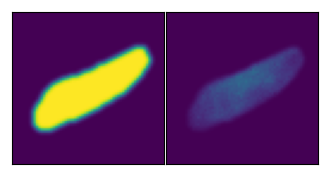

In [14]:
# Visualize the extracted single cell images for a specific cell ID
import scportrait

cell_id = 5778
image_of_cell = scportrait.tl.h5sc.get_image_with_cellid(project.h5sc, cell_id)
print(image_of_cell.shape)
fig, axs = plt.subplots(1, 1, figsize=(2 * 2, 2))
scportrait.pl.h5sc._plot_image_grid(ax=axs, images=image_of_cell, nrows=1, ncols=2)

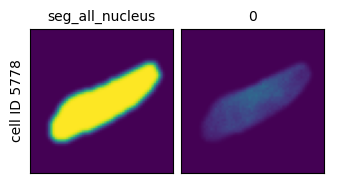

In [15]:
scportrait.pl.cell_grid(project.h5sc, cell_ids=cell_id)

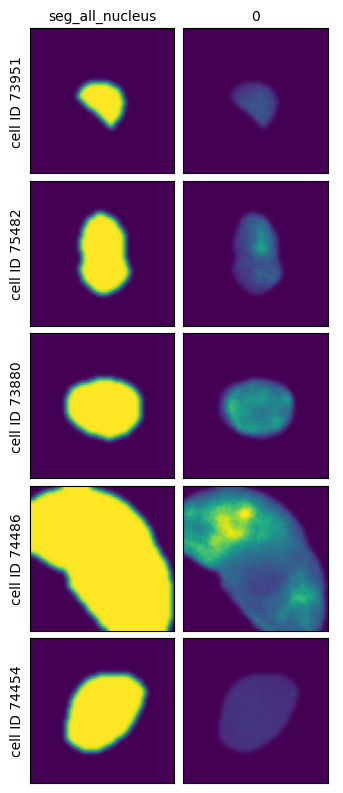

In [16]:
# Visualize the extracted single cell images for randomly selected cell IDs
project.plot_single_cell_images()


## Featurization - using CellFeaturizer

In [17]:
display(Markdown(f"```yaml\n{yaml.dump(project.featurization_f.config, default_flow_style=False)}\n```"))

```yaml
batch_size: 900
cache: /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks
dataloader_worker_number: 0
inference_device: cpu

```

In [18]:
project.featurize(overwrite = True)

Using extraction directory: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/extraction/data/single_cells.h5sc
[11/07/2026 21:34:02] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_uhzosdh0 for CellFeaturizer
[11/07/2026 21:34:02] Started CellFeaturization of all available channels.
[11/07/2026 21:34:02] Created new directory for featurization results: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/featurization/complete_CellFeaturizer
[11/07/2026 21:34:02] Initialized temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_az0clbvo for CellFeaturizer
[11/07/2026 21:34:02] Reading data from path: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/extraction/data/singl

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar

[11/07/2026 21:34:04] Table CellFeaturizer_nucleus written to sdata object.
[11/07/2026 21:34:04] GPU memory before performing cleanup: None
[11/07/2026 21:34:04] GPU memory after performing cleanup: None
[11/07/2026 21:34:05] Cleaned up temporary directory at /scratch/tmurugan/scportrait-spatial-omics-qc/notebooks/CellFeaturizer_az0clbvo


In [20]:
# Examine the SpatialData object after featurization
project.sdata

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/scportrait.sdata
├── Images
│     ├── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
│     ├── 'morphology_focus': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
│     ├── 'morphology_focus_rescaled': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
│     └── 'morphology_mip': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
├── Points
│     ├── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
│     └── 'transcript

## Generated Results

In [21]:
# View the extracted features for the segmented nuclei
results = project.sdata["CellFeaturizer_nucleus"].to_df()
print(results.head())

   nucleus_area  0_mean_nucleus  0_median_nucleus  0_quant75_nucleus  \
0        1228.0        0.199018          0.194153           0.374146   
1         466.0        0.063753          0.015865           0.140076   
2        1475.0        0.099902          0.079041           0.180908   
3         651.0        0.045348          0.018509           0.092957   
4        3222.0        0.227278          0.261475           0.348145   

   0_quant25_nucleus  0_summed_intensity_nucleus  \
0           0.001828                  244.393875   
1           0.000144                   29.708765   
2           0.000534                  147.355377   
3           0.000201                   29.521643   
4           0.051956                  732.289001   

   0_summed_intensity_area_normalized_nucleus  
0                                    0.199018  
1                                    0.063753  
2                                    0.099902  
3                                    0.045348  
4             

In [22]:
results["nucleus_area"].describe()

count    3933.000000
mean     1543.310181
std       748.818542
min       307.000000
25%      1005.000000
50%      1365.000000
75%      1999.000000
max      4085.000000
Name: nucleus_area, dtype: float64

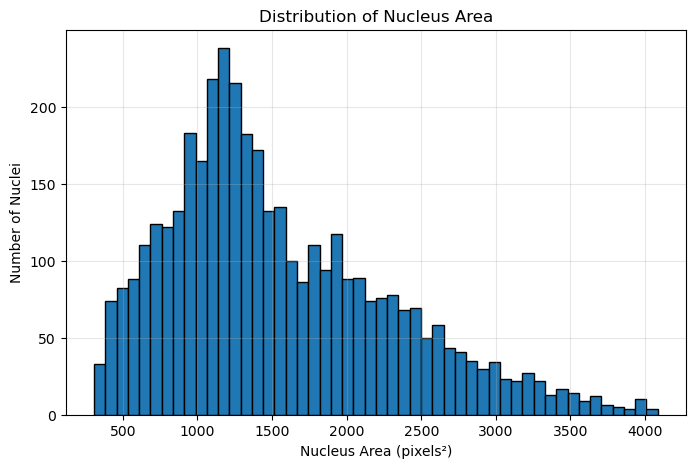

In [23]:
# Plot the histogram of nucleus area
plt.figure(figsize=(8, 5))

plt.hist(results["nucleus_area"], bins=50, edgecolor="black")

plt.title("Distribution of Nucleus Area")
plt.xlabel("Nucleus Area (pixels²)")
plt.ylabel("Number of Nuclei")

plt.grid(alpha=0.3)
plt.show()

## Clustering (based on nuclei features from `CellFeaturizer`)

In [24]:
# Keep only numeric features
X = results.select_dtypes(include=np.number)

print(X.shape)
X.head()

(3933, 7)


,nucleus_area,0_mean_nucleus,0_median_nucleus,0_quant75_nucleus,0_quant25_nucleus,0_summed_intensity_nucleus,0_summed_intensity_area_normalized_nucleus
0,1228.0,0.199018,0.194153,0.374146,0.001828,244.393875,0.199018
1,466.0,0.063753,0.015865,0.140076,0.000144,29.708765,0.063753
2,1475.0,0.099902,0.079041,0.180908,0.000534,147.355377,0.099902
3,651.0,0.045348,0.018509,0.092957,0.000201,29.521643,0.045348
4,3222.0,0.227278,0.261475,0.348145,0.051956,732.289001,0.227278


In [25]:
# Create an AnnData object for the extracted features
import anndata as ad

adata_feat = ad.AnnData(X)
adata_feat.obs_names = results.index.astype(str)

In [26]:
# Perform dimensional reduction and clustering based on the extracted features
import scanpy as sc
from sklearn.preprocessing import StandardScaler

adata_feat.X = StandardScaler().fit_transform(adata_feat.X)

sc.tl.pca(adata_feat)
sc.pp.neighbors(adata_feat, n_neighbors=15, n_pcs=20)
sc.tl.umap(adata_feat)
sc.tl.leiden(
    adata_feat,
    resolution=0.5,
    key_added="morphology_cluster_label"
)

adata_feat.obs["morphology_cluster_label"].value_counts()

/tmp/ipykernel_1939174/3374749162.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


morphology_cluster_label
0     365
1     361
2     352
3     345
4     344
5     339
6     296
7     285
8     283
9     272
10    260
11    207
12    170
13     54
Name: count, dtype: int64

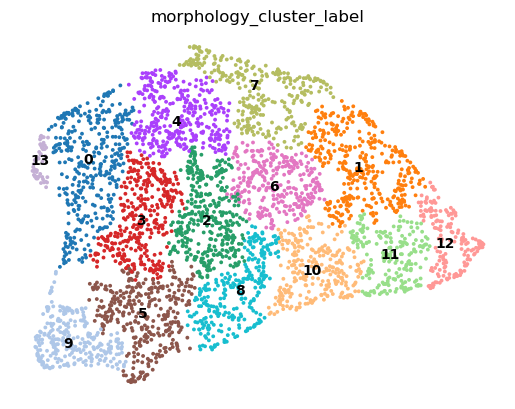

In [27]:
# Visualize the UMAP embedding colored by 'morphology_cluster_label'
sc.pl.umap(
    adata_feat,
    color="morphology_cluster_label",
    legend_loc="on data",
    frameon=False,
)

In [28]:
# Inspect the SpatialData object (to append the cluster labels to the 'tables' element of the SpatialData object)
print(project.sdata) 
print(project.sdata.tables)

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_xenium_segmentation_cropped_project/scportrait.sdata
├── Images
│     ├── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
│     ├── 'morphology_focus': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
│     ├── 'morphology_focus_rescaled': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
│     └── 'morphology_mip': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 1125, 1000), (1, 562, 500), (1, 281, 250)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (1125, 1000), (562, 500), (281, 250)
├── Points
│     ├── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
│     └── 'transcript

In [29]:
# Create a copy of the 'CellFeaturizer_nucleus' table and add the 'morphology_cluster_label' to it
feat_adata = project.sdata.tables["CellFeaturizer_nucleus"].copy()
feat_adata.obs["morphology_cluster_label"] = (
    adata_feat.obs.loc[feat_adata.obs_names, "morphology_cluster_label"].values
)

In [31]:
# Create a new SpatialData object with all the elements and the updated table and write it to a new path
from pathlib import Path
from spatialdata import SpatialData

output_path = Path("../data/results/xenium_noseg_cellfeaturizer.sdata.zarr")
output_path.parent.mkdir(parents=True, exist_ok=True)

sdata_result = SpatialData(
    images=dict(project.sdata.images),
    labels=dict(project.sdata.labels),
    points=dict(project.sdata.points),
    shapes=dict(project.sdata.shapes),
    tables={
        "CellFeaturizer_nucleus": feat_adata,
    },
)

sdata_result.write(output_path)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar